# MinHash Similarity antar Dokumen

Studi kasus: **10 dokumen pendek**, di mana **1 dokumen = 1 kalimat**. Korpus
dibuat manual (tidak lagi mengekstrak isi PDF jurnal dan tidak ada pemotongan
bab dengan RegEx), bertema mahasiswa, kampus, perpustakaan digital, dan data
mining sehingga terdapat beberapa pasangan kalimat yang mirip.

| Dokumen | Kalimat |
|---|---|
| **D1** | Mahasiswa belajar data mining di laboratorium kampus. |
| **D2** | Mahasiswa mempelajari data mining untuk analisis data. |
| **D3** | Perpustakaan digital membantu mahasiswa mencari jurnal. |
| **D4** | Sistem informasi kampus menyediakan jurnal digital. |
| **D5** | Data mining digunakan untuk menemukan pola informasi. |
| **D6** | Mahasiswa menggunakan jurnal digital untuk penelitian. |
| **D7** | Analisis data membantu pengambilan keputusan kampus. |
| **D8** | Perpustakaan kampus menyediakan akses informasi digital. |
| **D9** | Penelitian data mining membutuhkan kumpulan data besar. |
| **D10** | Sistem digital kampus membantu mahasiswa belajar online. |

## Pipeline notebook
1. **Definisi korpus** — 10 kalimat sebagai D1–D10 (tanpa ekstraksi PDF / RegEx bab)
2. **Preprocessing** (case folding → cleaning → tokenizing → stopword removal → stemming)
3. **Pembangunan Shingle Set** (k-shingle dari token; default `k=1` = kata)
4. **Min-Hash Signature Matrix** (fungsi hash acak universal)
5. **Jaccard Similarity Eksak** (ground truth)
6. **Estimasi Jaccard Similarity** dari signature Min-Hash
7. **LSH Banding** (deteksi kandidat pasangan mirip)
8. **Analisis akurasi** terhadap jumlah fungsi hash + ringkasan


## 0. Install dependencies (sekali saja)

In [1]:
# Pasang library yang dibutuhkan (jalankan sekali di environment baru / Colab)
!pip install -q PySastrawi numpy pandas matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import math
import re
import hashlib
import random
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

print('Import dan konfigurasi selesai. Teks tabel tidak dipotong.')

Import dan konfigurasi selesai. Teks tabel tidak dipotong.


## LANGKAH 1 — Definisi korpus 10 dokumen (1 dokumen = 1 kalimat)

Tidak ada lagi ekstraksi PDF maupun pemotongan bab dengan RegEx. Korpus
didefinisikan langsung sebagai **10 kalimat pendek**; setiap kalimat utuh
adalah satu dokumen (D1–D10).

Output langkah ini:
* `dokumen` — dict `{id: kalimat}` yang dipakai seluruh langkah berikutnya.
* `label_dokumen` — menyimpan teks asli tiap kalimat untuk ditampilkan di tabel.

In [3]:
# Korpus: 10 dokumen pendek, 1 dokumen = 1 kalimat (tanpa ekstraksi PDF / RegEx).
dokumen = {
    'D1': 'Mahasiswa belajar data mining di laboratorium kampus.',
    'D2': 'Mahasiswa mempelajari data mining untuk analisis data.',
    'D3': 'Perpustakaan digital membantu mahasiswa mencari jurnal.',
    'D4': 'Sistem informasi kampus menyediakan jurnal digital.',
    'D5': 'Data mining digunakan untuk menemukan pola informasi.',
    'D6': 'Mahasiswa menggunakan jurnal digital untuk penelitian.',
    'D7': 'Analisis data membantu pengambilan keputusan kampus.',
    'D8': 'Perpustakaan kampus menyediakan akses informasi digital.',
    'D9': 'Penelitian data mining membutuhkan kumpulan data besar.',
    'D10': 'Sistem digital kampus membantu mahasiswa belajar online.',
}

# Label dokumen = teks kalimat aslinya (dipakai di tabel-tabel selanjutnya).
label_dokumen = dict(dokumen)

print(f'Total dokumen: {len(dokumen)}  (1 dokumen = 1 kalimat)')
print('=' * 78)
df_korpus = pd.DataFrame({
    'Dokumen': list(dokumen.keys()),
    'Kalimat': list(dokumen.values()),
    'Jumlah Kata': [len(t.split()) for t in dokumen.values()],
})
display(df_korpus)

Total dokumen: 10  (1 dokumen = 1 kalimat)


,Dokumen,Kalimat,Jumlah Kata
0,D1,Mahasiswa belajar data mining di laboratorium kampus.,7
1,D2,Mahasiswa mempelajari data mining untuk analisis data.,7
2,D3,Perpustakaan digital membantu mahasiswa mencari jurnal.,6
3,D4,Sistem informasi kampus menyediakan jurnal digital.,6
4,D5,Data mining digunakan untuk menemukan pola informasi.,7
5,D6,Mahasiswa menggunakan jurnal digital untuk penelitian.,6
6,D7,Analisis data membantu pengambilan keputusan kampus.,6
7,D8,Perpustakaan kampus menyediakan akses informasi digital.,6
8,D9,Penelitian data mining membutuhkan kumpulan data besar.,7
9,D10,Sistem digital kampus membantu mahasiswa belajar online.,7


## LANGKAH 2 — Preprocessing

Pipeline `preprocess(text)` untuk tiap kalimat:
1. Case folding
2. Cleaning (regex: hapus angka dan tanda baca)
3. Tokenizing
4. Stopword Removal (`StopWordRemoverFactory`)
5. Stemming (`StemmerFactory`)

In [4]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    teks_tanpa_stopword = stopword_remover.remove(' '.join(tokens))
    tokens_tanpa_stopword = teks_tanpa_stopword.split()
    tokens_stem = [stemmer.stem(token) for token in tokens_tanpa_stopword]
    return tokens_stem

hasil_preproses = {nama_dok: preprocess(teks) for nama_dok, teks in dokumen.items()}

df_preproses = pd.DataFrame({
    'Dokumen': list(hasil_preproses.keys()),
    'Kalimat Asli': [label_dokumen[d] for d in hasil_preproses.keys()],
    'Token Hasil Preprocessing': [' '.join(v) for v in hasil_preproses.values()]
})
display(df_preproses)

,Dokumen,Kalimat Asli,Token Hasil Preprocessing
0,D1,Mahasiswa belajar data mining di laboratorium kampus.,mahasiswa ajar data mining laboratorium kampus
1,D2,Mahasiswa mempelajari data mining untuk analisis data.,mahasiswa ajar data mining analisis data
2,D3,Perpustakaan digital membantu mahasiswa mencari jurnal.,pustaka digital bantu mahasiswa cari jurnal
3,D4,Sistem informasi kampus menyediakan jurnal digital.,sistem informasi kampus sedia jurnal digital
4,D5,Data mining digunakan untuk menemukan pola informasi.,data mining temu pola informasi
5,D6,Mahasiswa menggunakan jurnal digital untuk penelitian.,mahasiswa jurnal digital teliti
6,D7,Analisis data membantu pengambilan keputusan kampus.,analisis data bantu ambil putus kampus
7,D8,Perpustakaan kampus menyediakan akses informasi digital.,pustaka kampus sedia akses informasi digital
8,D9,Penelitian data mining membutuhkan kumpulan data besar.,teliti data mining butuh kumpul data
9,D10,Sistem digital kampus membantu mahasiswa belajar online.,sistem digital kampus bantu mahasiswa ajar online


In [5]:
# ============================================================
# LANGKAH B — Shingling
# ============================================================
K_SHINGLE = 1  # ukuran shingle; utk dokumen 1-kalimat k=1 (kata) paling informatif — coba juga k=2 (bigram)

def buat_shingle(tokens: list, k: int) -> set:
    """
    Buat himpunan k-shingle dari list token.
    Shingle direpresentasikan sebagai tuple (immutable) agar bisa masuk set.
    """
    if len(tokens) < k:
        # Jika token lebih sedikit dari k, pakai unigram
        return {tuple(tokens)}
    return {tuple(tokens[i:i+k]) for i in range(len(tokens) - k + 1)}

# Buat shingle set untuk setiap dokumen
shingle_set = {
    dok: buat_shingle(tokens, K_SHINGLE)
    for dok, tokens in hasil_preproses.items()
}

# Daftar nama dokumen (urut sesuai dokumen) untuk dipakai di langkah berikutnya
nama_dokumen = list(shingle_set.keys())

# Tampilkan ringkasan
print(f'K-Shingle: {K_SHINGLE}')
print('=' * 60)
df_shingle = pd.DataFrame({
    'Dokumen': list(shingle_set.keys()),
    'Jumlah Token': [len(hasil_preproses[d]) for d in shingle_set.keys()],
    'Jumlah Shingle Unik': [len(s) for s in shingle_set.values()],
    'Contoh Shingle (3 pertama)': [
        str(list(shingle_set[d])[:3]) for d in shingle_set.keys()
    ]
})
display(df_shingle)

# Universal shingle universe (gabungan semua shingle)
universe = sorted({s for sset in shingle_set.values() for s in sset})
shingle_index = {s: i for i, s in enumerate(universe)}  # mapping shingle → indeks integer
print(f'\nUkuran Universe Shingle: {len(universe)} shingle unik')


K-Shingle: 1


,Dokumen,Jumlah Token,Jumlah Shingle Unik,Contoh Shingle (3 pertama)
0,D1,6,6,"[('kampus',), ('data',), ('mining',)]"
1,D2,6,5,"[('analisis',), ('data',), ('mining',)]"
2,D3,6,6,"[('digital',), ('pustaka',), ('cari',)]"
3,D4,6,6,"[('kampus',), ('digital',), ('jurnal',)]"
4,D5,5,5,"[('data',), ('mining',), ('pola',)]"
5,D6,4,4,"[('digital',), ('jurnal',), ('mahasiswa',)]"
6,D7,6,6,"[('kampus',), ('analisis',), ('putus',)]"
7,D8,6,6,"[('kampus',), ('digital',), ('pustaka',)]"
8,D9,6,5,"[('data',), ('teliti',), ('mining',)]"
9,D10,7,7,"[('kampus',), ('digital',), ('bantu',)]"



Ukuran Universe Shingle: 24 shingle unik


## LANGKAH C — Jaccard Similarity Eksak (Rumus 1)

Ukuran kemiripan antar dua himpunan: rasio elemen yang sama (irisan) terhadap
total elemen unik (gabungan).

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

* $A$, $B$ = himpunan shingle dari dua dokumen
* Nilai $0$ = tidak ada shingle yang sama, $1$ = identik

Cell di bawah membangun matriks Jaccard eksak $10 \times 10$ sebagai **ground
truth** — referensi untuk mengevaluasi seberapa akurat estimasi Min-Hash di
LANGKAH E.

In [6]:
# ============================================================
# LANGKAH C — Jaccard Similarity Eksak
# ============================================================
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Hitung Jaccard Similarity eksak antara dua himpunan."""
    if not set_a and not set_b:
        return 1.0  # keduanya kosong → identik
    irisan = len(set_a & set_b)
    gabungan = len(set_a | set_b)
    return irisan / gabungan if gabungan > 0 else 0.0

# Hitung matriks Jaccard eksak
N_DOK = len(nama_dokumen)
matrix_jaccard_eksak = pd.DataFrame(
    index=nama_dokumen, columns=nama_dokumen, dtype=float
)

for di in nama_dokumen:
    for dj in nama_dokumen:
        matrix_jaccard_eksak.loc[di, dj] = jaccard_similarity(
            shingle_set[di], shingle_set[dj]
        )

print('MATRIKS JACCARD SIMILARITY EKSAK (Ground Truth)')
print('=' * 60)
display(matrix_jaccard_eksak.round(4))

MATRIKS JACCARD SIMILARITY EKSAK (Ground Truth)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
D1,1.0000,0.5714,0.0909,0.0909,0.2222,0.1111,0.2000,0.0909,0.2222,0.3000
D2,0.5714,1.0000,0.1000,0.0000,0.2500,0.1250,0.2222,0.0000,0.2500,0.2000
D3,0.0909,0.1000,1.0000,0.2000,0.0000,0.4286,0.0909,0.2000,0.0000,0.3000
D4,0.0909,0.0000,0.2000,1.0000,0.1000,0.2500,0.0909,0.5000,0.0000,0.3000
D5,0.2222,0.2500,0.0000,0.1000,1.0000,0.0000,0.1000,0.1000,0.2500,0.0000
D6,0.1111,0.1250,0.4286,0.2500,0.0000,1.0000,0.0000,0.1111,0.1250,0.2222
D7,0.2000,0.2222,0.0909,0.0909,0.1000,0.0000,1.0000,0.0909,0.1000,0.1818
D8,0.0909,0.0000,0.2000,0.5000,0.1000,0.1111,0.0909,1.0000,0.0000,0.1818
D9,0.2222,0.2500,0.0000,0.0000,0.2500,0.1250,0.1000,0.0000,1.0000,0.0000
D10,0.3000,0.2000,0.3000,0.3000,0.0000,0.2222,0.1818,0.1818,0.0000,1.0000


## LANGKAH D — Hash Function & MinHash Signature (Rumus 2 & 3)

### Rumus 2 — Hash function universal

$$h(x) = (a \cdot x + b) \bmod p$$

* $a, b$ = bilangan acak konstan (berbeda untuk tiap fungsi hash)
* $p$ = bilangan prima besar (di code: `PRIME = 4_294_967_311`)
* $x$ = indeks integer dari shingle dalam universe

Kita generate $K$ pasang $(a, b)$ acak → menghasilkan $K$ fungsi hash berbeda
$h_1, h_2, \dots, h_K$. Bilangan prima besar dipakai supaya distribusi hash
mendekati uniform di seluruh range bilangan bulat.

### Rumus 3 — MinHash signature

$$\text{minhash}_k(S) = \min_{x \in S} h_k(x)$$

Untuk tiap fungsi hash $h_k$, ambil **nilai minimum** dari hasil hash pada
seluruh shingle dokumen $S$. Hasilnya: vektor signature panjang $K$ yang
"merangkum" set shingle dokumen — bayangkan seperti sidik jari ringkas.

Cell di bawah membangkitkan parameter $(a, b)$, mengimplementasikan kedua
rumus, lalu menyusun signature matrix $K \times N$ untuk semua dokumen.

In [7]:
# ============================================================
# LANGKAH D — Signature Matrix Min-Hash
# ============================================================
N_HASH = 100      # jumlah fungsi hash; makin besar = makin akurat
PRIME = 4294967311  # bilangan prima besar (> ukuran universe yang mungkin)

random.seed(42)  # untuk reprodusibilitas

# Generate n pasang (a, b) acak untuk fungsi hash h(x) = (a*x + b) mod PRIME
params_hash = [
    (random.randint(1, PRIME - 1), random.randint(0, PRIME - 1))
    for _ in range(N_HASH)
]

def minhash_signature(shingle_indices: list, params: list, prime: int) -> list:
    """
    Hitung signature Min-Hash dari sebuah dokumen.

    Args:
        shingle_indices: list indeks integer dari shingle dokumen ini
        params: list (a, b) untuk tiap fungsi hash
        prime: bilangan prima untuk modulo
    Returns:
        list nilai minimum hash (signature vector)
    """
    if not shingle_indices:
        return [0] * len(params)  # dokumen kosong

    signature = []
    for a, b in params:
        # Hitung h(x) = (a*x + b) mod p untuk setiap shingle, ambil minimum
        min_hash = min((a * x + b) % prime for x in shingle_indices)
        signature.append(min_hash)
    return signature

# Konversi shingle set ke indeks integer
shingle_indices_per_dok = {
    dok: [shingle_index[s] for s in sset]
    for dok, sset in shingle_set.items()
}

# Hitung signature untuk setiap dokumen
signatures = {
    dok: minhash_signature(shingle_indices_per_dok[dok], params_hash, PRIME)
    for dok in nama_dokumen
}

# Tampilkan signature matrix (10 hash pertama)
print(f'Signature Matrix Min-Hash (N_HASH={N_HASH}, ditampilkan 10 pertama)')
print('=' * 70)
df_signature = pd.DataFrame(
    {dok: signatures[dok][:10] for dok in nama_dokumen},
    index=[f'h{i+1}' for i in range(10)]
)
display(df_signature)

Signature Matrix Min-Hash (N_HASH=100, ditampilkan 10 pertama)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
h1,974977140,830258963,479275983,128293003,128293003,974977140,830258963,128293003,1470678297,974977140
h2,363493246,363493246,325282245,823729169,363493246,2242647939,785518168,823729169,363493246,823729169
h3,127978094,127978094,1069513270,1069513270,869594431,1069513270,198908004,1740199697,398826843,127978094
h4,323871916,323871916,1262914872,585571367,323871916,1262914872,323871916,1262914872,323871916,185323898
h5,60612650,568438965,1515224214,60612650,568438965,1515224214,60612650,60612650,568438965,60612650
h6,746421115,496486023,621453569,621453569,996356207,621453569,37388708,621453569,1455453522,621453569
h7,667779376,667779376,846033884,935161138,935161138,2396525993,756906630,935161138,1024288392,667779376
h8,398340369,398340369,482381263,524401710,524401710,1970064296,440360816,524401710,566422157,398340369
h9,450143917,591174348,865537605,2668142788,309113486,865537605,175780660,2527112357,34750229,865537605
h10,142637904,142637904,953621858,1033637705,142637904,382685445,62622057,1033637705,142637904,953621858


## LANGKAH E — Estimasi Jaccard via MinHash (Rumus 4)

Trik utama Min-Hash: probabilitas dua dokumen punya **nilai signature sama** di
fungsi hash ke-$k$ secara matematis sama dengan Jaccard similarity-nya. Jadi
cukup hitung proporsi posisi yang cocok antar dua signature.

$$\hat{J}(A, B) = \frac{1}{K} \sum_{k=1}^{K} \mathbb{1}\bigl[\text{minhash}_k(A) = \text{minhash}_k(B)\bigr]$$

* $K$ = jumlah fungsi hash (di code: `N_HASH`)
* $\mathbb{1}[\cdot]$ = fungsi indikator (bernilai $1$ jika benar, $0$ jika salah)
* $\hat{J}$ = estimasi Jaccard dari signature

Semakin besar $K$, estimasi makin mendekati nilai eksak — properti ini akan
dibuktikan secara empiris di LANGKAH H. Cell di bawah menghitung matriks
estimasi $10 \times 10$ sekaligus membandingkannya dengan ground truth (Rumus 1).

In [8]:
# ============================================================
# LANGKAH E — Estimasi Jaccard Similarity dari Signature
# ============================================================
def estimasi_jaccard_minhash(sig_a: list, sig_b: list) -> float:
    """Estimasi Jaccard Similarity dari dua signature Min-Hash."""
    cocok = sum(1 for ha, hb in zip(sig_a, sig_b) if ha == hb)
    return cocok / len(sig_a)

# Bangun matriks estimasi Min-Hash
matrix_minhash = pd.DataFrame(
    index=nama_dokumen, columns=nama_dokumen, dtype=float
)

for di in nama_dokumen:
    for dj in nama_dokumen:
        matrix_minhash.loc[di, dj] = estimasi_jaccard_minhash(
            signatures[di], signatures[dj]
        )

print(f'MATRIKS ESTIMASI JACCARD (Min-Hash, N_HASH={N_HASH})')
print('=' * 60)
display(matrix_minhash.round(4))

# Hitung error estimasi
print('\nPERBANDINGAN EKSAK vs ESTIMASI (pasangan unik)')
print('=' * 75)
rows_perbandingan = []
for di, dj in itertools.combinations(nama_dokumen, 2):
    eksak = matrix_jaccard_eksak.loc[di, dj]
    estimasi = matrix_minhash.loc[di, dj]
    error = abs(eksak - estimasi)
    rows_perbandingan.append({
        'Pasangan': f'{di} – {dj}',
        'Jaccard Eksak': round(eksak, 4),
        'Estimasi Min-Hash': round(estimasi, 4),
        'Error Absolut': round(error, 4)
    })

df_perbandingan = pd.DataFrame(rows_perbandingan)
display(df_perbandingan)
print(f'\nRata-rata Error Absolut: {df_perbandingan["Error Absolut"].mean():.4f}')
print(f'Error Maksimum        : {df_perbandingan["Error Absolut"].max():.4f}')

MATRIKS ESTIMASI JACCARD (Min-Hash, N_HASH=100)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
D1,1.00,0.64,0.10,0.08,0.21,0.12,0.12,0.06,0.25,0.37
D2,0.64,1.00,0.07,0.00,0.24,0.08,0.16,0.00,0.26,0.24
D3,0.10,0.07,1.00,0.19,0.00,0.40,0.11,0.18,0.00,0.35
D4,0.08,0.00,0.19,1.00,0.12,0.18,0.13,0.58,0.00,0.28
D5,0.21,0.24,0.00,0.12,1.00,0.00,0.08,0.12,0.23,0.00
D6,0.12,0.08,0.40,0.18,0.00,1.00,0.00,0.11,0.15,0.21
D7,0.12,0.16,0.11,0.13,0.08,0.00,1.00,0.11,0.09,0.21
D8,0.06,0.00,0.18,0.58,0.12,0.11,0.11,1.00,0.00,0.17
D9,0.25,0.26,0.00,0.00,0.23,0.15,0.09,0.00,1.00,0.00
D10,0.37,0.24,0.35,0.28,0.00,0.21,0.21,0.17,0.00,1.00



PERBANDINGAN EKSAK vs ESTIMASI (pasangan unik)


,Pasangan,Jaccard Eksak,Estimasi Min-Hash,Error Absolut
0,D1 – D2,0.5714,0.64,0.0686
1,D1 – D3,0.0909,0.10,0.0091
2,D1 – D4,0.0909,0.08,0.0109
3,D1 – D5,0.2222,0.21,0.0122
4,D1 – D6,0.1111,0.12,0.0089
5,D1 – D7,0.2000,0.12,0.0800
6,D1 – D8,0.0909,0.06,0.0309
7,D1 – D9,0.2222,0.25,0.0278
8,D1 – D10,0.3000,0.37,0.0700
9,D2 – D3,0.1000,0.07,0.0300



Rata-rata Error Absolut: 0.0231
Error Maksimum        : 0.0800


In [9]:
# ============================================================
# LANGKAH F — LSH Banding
# ============================================================
B = 25   # jumlah band
R = N_HASH // B  # jumlah baris per band (harus habis dibagi)

assert N_HASH % B == 0, f'N_HASH ({N_HASH}) harus habis dibagi B ({B})'

threshold_lsh = (1 / B) ** (1 / R)
print(f'Konfigurasi LSH: B={B} band, R={R} baris/band')
print(f'Threshold similaritas ≈ {threshold_lsh:.4f}')
print('(Pasangan dengan Jaccard > threshold kemungkinan besar akan terdeteksi)')
print('=' * 60)

def lsh_banding(signatures: dict, b: int, r: int) -> set:
    """
    Temukan kandidat pasangan dokumen mirip menggunakan LSH Banding.

    Returns:
        Set of tuple (dokA, dokB) yang merupakan kandidat mirip.
    """
    kandidat = set()
    nama_dok_list = list(signatures.keys())

    for band_idx in range(b):
        # Bucket untuk band ini: hash(signature band) → list dokumen
        bucket = {}
        for dok, sig in signatures.items():
            # Ambil potongan signature untuk band ini
            awal = band_idx * r
            akhir = awal + r
            band_sig = tuple(sig[awal:akhir])

            # Hash tuple ke bucket
            kunci = hash(band_sig)  # Python built-in hash
            bucket.setdefault(kunci, []).append(dok)

        # Dokumen dalam bucket yang sama = kandidat
        for dok_dalam_bucket in bucket.values():
            if len(dok_dalam_bucket) > 1:
                for pasangan in itertools.combinations(dok_dalam_bucket, 2):
                    kandidat.add(tuple(sorted(pasangan)))

    return kandidat

kandidat_mirip = lsh_banding(signatures, B, R)

# Verifikasi kandidat dengan Jaccard eksak
print(f'Total kandidat pasangan ditemukan LSH: {len(kandidat_mirip)}')
print()

if kandidat_mirip:
    rows_lsh = []
    for di, dj in sorted(kandidat_mirip):
        sim_eksak = matrix_jaccard_eksak.loc[di, dj]
        sim_estimasi = matrix_minhash.loc[di, dj]
        rows_lsh.append({
            'Pasangan Kandidat': f'{di} – {dj}',
            'Jaccard Eksak': round(sim_eksak, 4),
            'Estimasi Min-Hash': round(sim_estimasi, 4),
            'Status': '✅ Mirip' if sim_eksak >= threshold_lsh else '⚠️ False Positive'
        })
    df_lsh = pd.DataFrame(rows_lsh)
    display(df_lsh)
else:
    print('Tidak ada kandidat pasangan terdeteksi pada threshold ini.')
    print(f'Coba turunkan threshold dengan memperbesar B atau perkecil R.')

Konfigurasi LSH: B=25 band, R=4 baris/band
Threshold similaritas ≈ 0.4472
(Pasangan dengan Jaccard > threshold kemungkinan besar akan terdeteksi)
Total kandidat pasangan ditemukan LSH: 4



,Pasangan Kandidat,Jaccard Eksak,Estimasi Min-Hash,Status
0,D1 – D2,0.5714,0.64,✅ Mirip
1,D10 – D3,0.3000,0.35,⚠️ False Positive
2,D10 – D4,0.3000,0.28,⚠️ False Positive
3,D4 – D8,0.5000,0.58,✅ Mirip


## LANGKAH G — Perankingan dokumen: Jaccard Eksak vs Estimasi Min-Hash

Salah satu dokumen dipilih sebagai **query**. Sembilan dokumen lain (plus dirinya
sendiri pada peringkat 1) diurutkan dari yang paling mirip ke query berdasarkan
**Jaccard eksak** (ground truth). Untuk tiap dokumen pada urutan itu, kita
tampilkan dua nilai dalam satu grafik garis:

* **Jaccard Eksak** — kemiripan sebenarnya (Rumus 1).
* **Estimasi Min-Hash** — kemiripan yang ditebak dari signature (Rumus 4).

Kalau garis Min-Hash menempel pada garis Jaccard eksak (dan menurun searah),
artinya Min-Hash berhasil mempertahankan **urutan peringkat** — bukan cuma nilai
absolutnya. Ganti `DOK_QUERY` untuk melihat ranking dari sudut pandang dokumen
lain.

PERANKINGAN 10 DOKUMEN TERHADAP QUERY = D1


,Peringkat,Dokumen,Kalimat,Jaccard Eksak,Estimasi Min-Hash,Selisih
0,1,D1,Mahasiswa belajar data mining di laboratorium kampus.,1.0000,1.00,0.0000
1,2,D2,Mahasiswa mempelajari data mining untuk analisis data.,0.5714,0.64,0.0686
2,3,D10,Sistem digital kampus membantu mahasiswa belajar online.,0.3000,0.37,0.0700
3,4,D5,Data mining digunakan untuk menemukan pola informasi.,0.2222,0.21,0.0122
4,5,D9,Penelitian data mining membutuhkan kumpulan data besar.,0.2222,0.25,0.0278
5,6,D7,Analisis data membantu pengambilan keputusan kampus.,0.2000,0.12,0.0800
6,7,D6,Mahasiswa menggunakan jurnal digital untuk penelitian.,0.1111,0.12,0.0089
7,8,D4,Sistem informasi kampus menyediakan jurnal digital.,0.0909,0.08,0.0109
8,9,D3,Perpustakaan digital membantu mahasiswa mencari jurnal.,0.0909,0.10,0.0091
9,10,D8,Perpustakaan kampus menyediakan akses informasi digital.,0.0909,0.06,0.0309


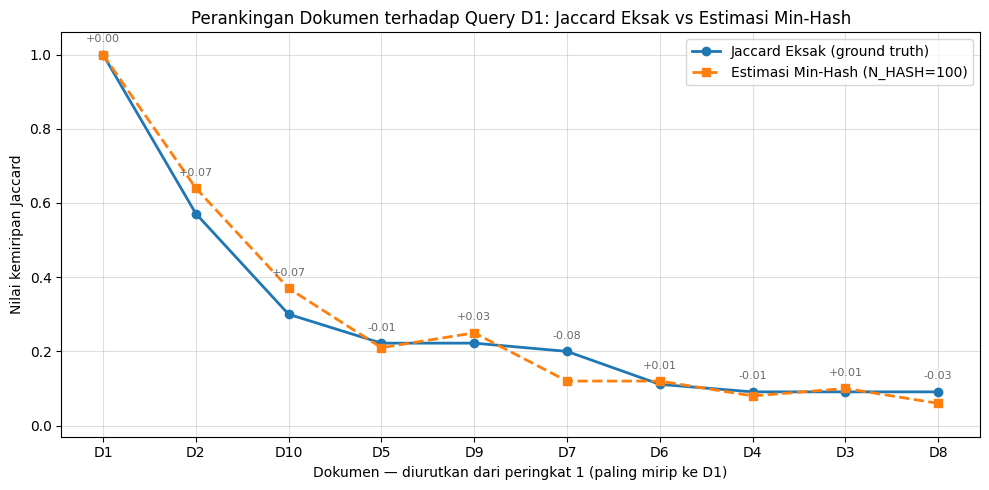

Plot disimpan sebagai minhash_perankingan.png


In [10]:
# ============================================================
# LANGKAH G — Perankingan dokumen terhadap satu query
# ============================================================
DOK_QUERY = 'D1'   # ganti ke 'D2', 'D3', ... untuk ranking dari dokumen lain

# Kemiripan query ke seluruh dokumen (D1..D10); query vs dirinya sendiri = 1.0
sim_eksak   = matrix_jaccard_eksak.loc[DOK_QUERY].astype(float)
sim_minhash = matrix_minhash.loc[DOK_QUERY].astype(float)

# Urutkan dokumen dari paling mirip ke query, pakai Jaccard eksak sebagai acuan
urutan = sim_eksak.sort_values(ascending=False).index.tolist()

df_rank = pd.DataFrame({
    'Peringkat'         : range(1, len(urutan) + 1),
    'Dokumen'           : urutan,
    'Kalimat'           : [label_dokumen[d] for d in urutan],
    'Jaccard Eksak'     : [round(sim_eksak[d], 4)   for d in urutan],
    'Estimasi Min-Hash' : [round(sim_minhash[d], 4) for d in urutan],
    'Selisih'           : [round(abs(sim_eksak[d] - sim_minhash[d]), 4) for d in urutan],
})
print(f'PERANKINGAN 10 DOKUMEN TERHADAP QUERY = {DOK_QUERY}')
print('=' * 70)
display(df_rank)

# --- Grafik garis: dokumen (urut peringkat) vs nilai kemiripan ---
fig, ax = plt.subplots(figsize=(10, 5))
x = list(range(len(urutan)))
y_eksak   = [sim_eksak[d]   for d in urutan]
y_minhash = [sim_minhash[d] for d in urutan]

ax.plot(x, y_eksak,   marker='o', linewidth=2,                  label='Jaccard Eksak (ground truth)')
ax.plot(x, y_minhash, marker='s', linewidth=2, linestyle='--',  label=f'Estimasi Min-Hash (N_HASH={N_HASH})')

ax.set_xticks(x)
ax.set_xticklabels(urutan)
ax.set_xlabel(f'Dokumen — diurutkan dari peringkat 1 (paling mirip ke {DOK_QUERY})')
ax.set_ylabel('Nilai kemiripan Jaccard')
ax.set_title(f'Perankingan Dokumen terhadap Query {DOK_QUERY}: Jaccard Eksak vs Estimasi Min-Hash')
ax.set_ylim(-0.03, 1.06)
ax.grid(True, alpha=0.4)
ax.legend()

# Anotasi selisih estimasi - eksak di tiap titik
for xi, d in zip(x, urutan):
    e, m = sim_eksak[d], sim_minhash[d]
    ax.annotate(f'{m - e:+.2f}', (xi, max(e, m)), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color='dimgray')

plt.tight_layout()
plt.savefig('minhash_perankingan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai minhash_perankingan.png')


ANALISIS AKURASI vs JUMLAH FUNGSI HASH


,N_Hash,Pasangan,Jaccard Eksak,Estimasi,Error
0,10,D1–D2,0.5714,0.600,0.0286
1,10,D4–D8,0.5000,0.700,0.2000
2,10,D3–D6,0.4286,0.500,0.0714
3,10,D1–D10,0.3000,0.500,0.2000
4,25,D1–D2,0.5714,0.600,0.0286
5,25,D4–D8,0.5000,0.680,0.1800
6,25,D3–D6,0.4286,0.360,0.0686
7,25,D1–D10,0.3000,0.280,0.0200
8,50,D1–D2,0.5714,0.580,0.0086
9,50,D4–D8,0.5000,0.580,0.0800


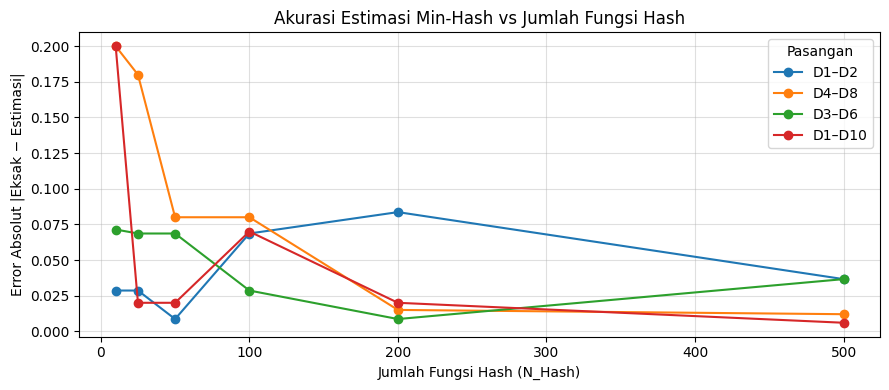

Plot disimpan sebagai minhash_akurasi.png


In [11]:
# ============================================================
# LANGKAH H — Analisis pengaruh N_HASH terhadap akurasi estimasi
# ============================================================
n_hash_list = [10, 25, 50, 100, 200, 500]

# Ambil 4 pasangan dengan Jaccard eksak tertinggi sebagai sampel uji
pasangan_uji = sorted(
    itertools.combinations(nama_dokumen, 2),
    key=lambda p: float(matrix_jaccard_eksak.loc[p[0], p[1]]),
    reverse=True,
)[:4]

print('ANALISIS AKURASI vs JUMLAH FUNGSI HASH')
print('=' * 70)

rows_analisis = []
for n in n_hash_list:
    random.seed(42)
    params_n = [
        (random.randint(1, PRIME - 1), random.randint(0, PRIME - 1))
        for _ in range(n)
    ]
    sigs_n = {
        dok: minhash_signature(shingle_indices_per_dok[dok], params_n, PRIME)
        for dok in nama_dokumen
    }
    for di, dj in pasangan_uji:
        eksak = matrix_jaccard_eksak.loc[di, dj]
        estimasi = estimasi_jaccard_minhash(sigs_n[di], sigs_n[dj])
        rows_analisis.append({
            'N_Hash': n,
            'Pasangan': f'{di}–{dj}',
            'Jaccard Eksak': round(float(eksak), 4),
            'Estimasi': round(estimasi, 4),
            'Error': round(abs(float(eksak) - estimasi), 4)
        })

df_analisis = pd.DataFrame(rows_analisis)
display(df_analisis)

# Plot error vs N_HASH
fig, ax = plt.subplots(figsize=(9, 4))
for pasangan in df_analisis['Pasangan'].unique():
    subset = df_analisis[df_analisis['Pasangan'] == pasangan]
    ax.plot(subset['N_Hash'], subset['Error'], marker='o', label=pasangan)

ax.set_xlabel('Jumlah Fungsi Hash (N_Hash)')
ax.set_ylabel('Error Absolut |Eksak − Estimasi|')
ax.set_title('Akurasi Estimasi Min-Hash vs Jumlah Fungsi Hash')
ax.legend(title='Pasangan', loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('minhash_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai minhash_akurasi.png')

In [12]:
# ============================================================
# LANGKAH I — Ringkasan & Kesimpulan
# ============================================================
print('=' * 70)
print('RINGKASAN IMPLEMENTASI MIN-HASH ANTAR-DOKUMEN')
print('=' * 70)
print(f'Dokumen     : {len(nama_dokumen)} dokumen ({", ".join(nama_dokumen)})')
print(f'K-Shingle   : {K_SHINGLE} (k=1 = kata/unigram)')
print(f'Universe    : {len(universe)} shingle unik')
print(f'N_Hash      : {N_HASH} fungsi hash')
print(f'LSH Config  : B={B} band × R={R} baris/band')
print(f'Threshold   : {threshold_lsh:.4f}')
print()

# Tampilkan semua pasangan dokumen terurut dari paling mirip
print('PASANGAN DOKUMEN (urut dari paling mirip, berdasarkan Jaccard Eksak):')
print('-' * 70)
rows_top = []
for di, dj in itertools.combinations(nama_dokumen, 2):
    eksak = float(matrix_jaccard_eksak.loc[di, dj])
    estimasi = float(matrix_minhash.loc[di, dj])
    rows_top.append({
        'Pasangan': f'{di} – {dj}',
        'Jaccard Eksak': round(eksak, 4),
        'Min-Hash Estimasi': round(estimasi, 4),
        'Error': round(abs(eksak - estimasi), 4)
    })

df_top = pd.DataFrame(rows_top).sort_values('Jaccard Eksak', ascending=False)
display(df_top.reset_index(drop=True))

print()
print('KESIMPULAN:')
mean_error = df_perbandingan['Error Absolut'].mean()
print(f'• Rata-rata error estimasi Min-Hash: {mean_error:.4f}')
print(f'• Makin besar N_Hash → makin kecil error (lihat Langkah H)')
print(f'• LSH menemukan {len(kandidat_mirip)} kandidat pasangan mirip')
print(f'  di atas threshold {threshold_lsh:.4f}')

RINGKASAN IMPLEMENTASI MIN-HASH ANTAR-DOKUMEN
Dokumen     : 10 dokumen (D1, D2, D3, D4, D5, D6, D7, D8, D9, D10)
K-Shingle   : 1 (k=1 = kata/unigram)
Universe    : 24 shingle unik
N_Hash      : 100 fungsi hash
LSH Config  : B=25 band × R=4 baris/band
Threshold   : 0.4472

PASANGAN DOKUMEN (urut dari paling mirip, berdasarkan Jaccard Eksak):
----------------------------------------------------------------------


,Pasangan,Jaccard Eksak,Min-Hash Estimasi,Error
0,D1 – D2,0.5714,0.64,0.0686
1,D4 – D8,0.5000,0.58,0.0800
2,D3 – D6,0.4286,0.40,0.0286
3,D1 – D10,0.3000,0.37,0.0700
4,D3 – D10,0.3000,0.35,0.0500
5,D4 – D10,0.3000,0.28,0.0200
6,D5 – D9,0.2500,0.23,0.0200
7,D2 – D9,0.2500,0.26,0.0100
8,D4 – D6,0.2500,0.18,0.0700
9,D2 – D5,0.2500,0.24,0.0100



KESIMPULAN:
• Rata-rata error estimasi Min-Hash: 0.0231
• Makin besar N_Hash → makin kecil error (lihat Langkah H)
• LSH menemukan 4 kandidat pasangan mirip
  di atas threshold 0.4472
